In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('train.csv')
print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

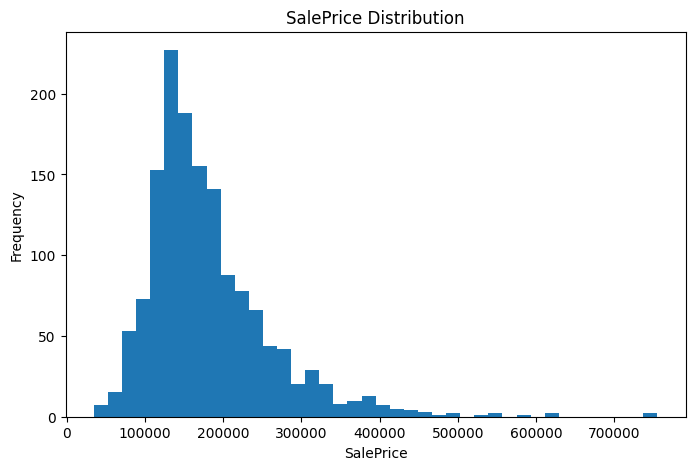

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df["SalePrice"], bins=40)
plt.title("SalePrice Distribution")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()


In [7]:
print("Skewness:", df["SalePrice"].skew())


Skewness: 1.8828757597682129


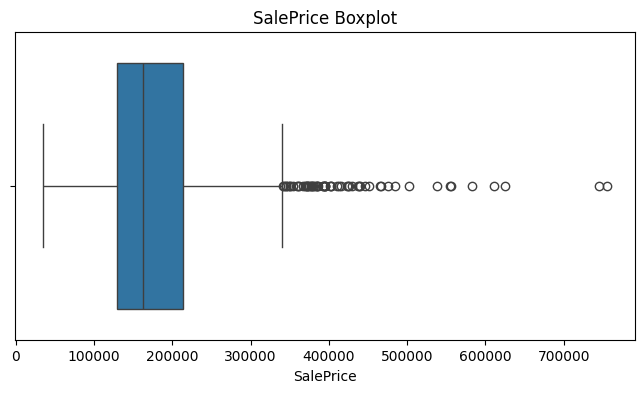

In [8]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["SalePrice"])
plt.title("SalePrice Boxplot")
plt.show()


In [10]:
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Alt sınır:", lower)
print("Üst sınır:", upper)

Alt sınır: 3937.5
Üst sınır: 340037.5


In [11]:
outliers = df[df["SalePrice"] > upper]

outliers.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
11,12,60,RL,85.0,11924,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,New,Partial,345000
53,54,20,RL,68.0,50271,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,385000
58,59,60,RL,66.0,13682,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,10,2006,New,Partial,438780
112,113,60,RL,77.0,9965,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,383970
151,152,20,RL,107.0,13891,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,New,Partial,372402


In [12]:
pip install feature-engine


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.4 MB/s eta 0:00:00


In [13]:
from feature_engine.outliers import Winsorizer

winsor = Winsorizer(
    capping_method="iqr",
    tail="right",
    fold=1.5,
    variables=["SalePrice"]
)

df_cap = winsor.fit_transform(df)

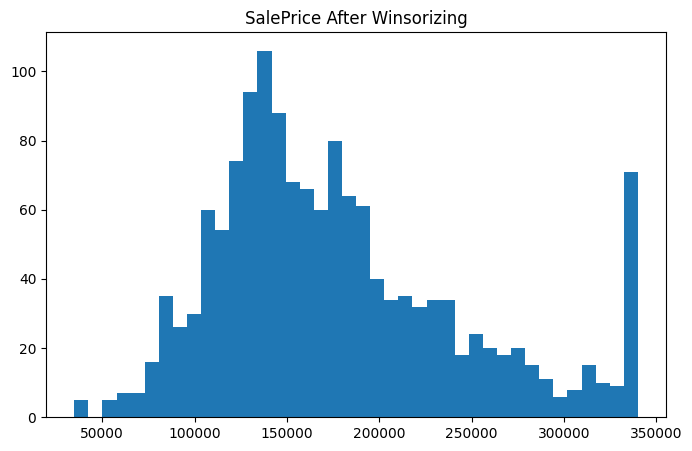

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df_cap["SalePrice"], bins=40)
plt.title("SalePrice After Winsorizing")
plt.show()

In [15]:
df["SalePrice_log"] = np.log1p(df["SalePrice"])


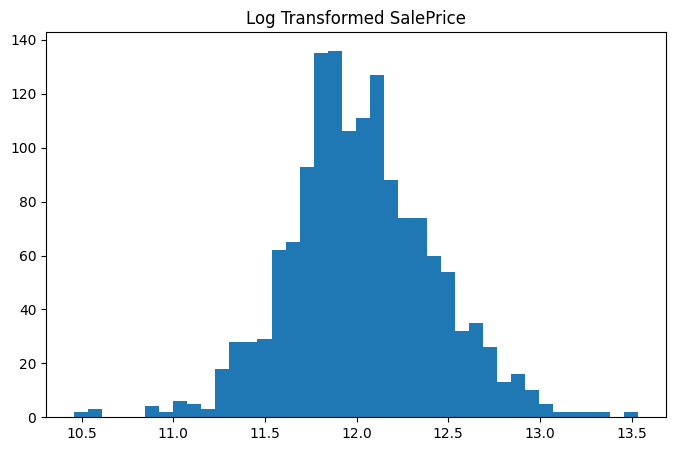

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df["SalePrice_log"], bins=40)
plt.title("Log Transformed SalePrice")
plt.show()

In [18]:
print("Before Log:", df["SalePrice"].skew())
print("After Log:", df["SalePrice_log"].skew())

Before Log: 1.8828757597682129
After Log: 0.12134661989685333
